# 01 · Train ResNet50 (Stage-1 Classifier)

This notebook trains the **first stage** of the cascaded plant-disease pipeline.

| Step | What happens |
|------|--------------|
| 1    | Load dataset with augmentation |
| 2    | Build ResNet50 with custom head |
| 3    | Phase 1 – train head only (base frozen) |
| 4    | Phase 2 – fine-tune last 20 layers |
| 5    | Evaluate on validation set |
| 6    | Save best model to `models/resnet_model.h5` |
| 7    | Plot accuracy / loss / confusion matrix |


## 0 · Environment setup

In [1]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [2]:
# ── Install dependencies (run once) ──────────────────────────────────────
# !pip install -r ../requirements.txt

import sys, os
sys.path.append(os.path.abspath(".."))   # so we can import src.*

import tensorflow as tf
print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.21.0
GPU available      : []


## 1 · Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR       = "../data"                       # root of the 53-class folders
MODEL_SAVE     = "../models/resnet_model.h5"     # where best checkpoint is saved

# ── Hyperparameters ───────────────────────────────────────────────────────
NUM_CLASSES    = 53
IMAGE_SIZE     = (224, 224)
BATCH_SIZE     = 16
EPOCHS_PHASE1  = 5    # head-only training
EPOCHS_PHASE2  = 2    # fine-tuning

os.makedirs("../models", exist_ok=True)

## 2 · Load dataset

In [4]:
from src.data_loader import get_data_generators, dataset_summary

# Print dataset stats
summary = dataset_summary(DATA_DIR)

# Build train / validation generators
train_gen, val_gen, CLASS_NAMES = get_data_generators(
    data_dir   = DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
)

# Verify
print("\nFirst 5 classes:", CLASS_NAMES[:5])
print("Total classes   :", len(CLASS_NAMES))


  Dataset Summary
  Root         : ../data
  Classes      : 58
  Total images : 94226

Found 75401 images belonging to 58 classes.
Found 18825 images belonging to 58 classes.
[data_loader] Found 58 classes.
[data_loader] Training   samples : 75401
[data_loader] Validation samples : 18825

First 5 classes: ['Apple___black_rot', 'Apple___cedar_rust', 'Apple___healthy', 'Apple___scab', 'Bell_pepper___bacterial_spot']
Total classes   : 58


### 2a · Visualise sample augmented images

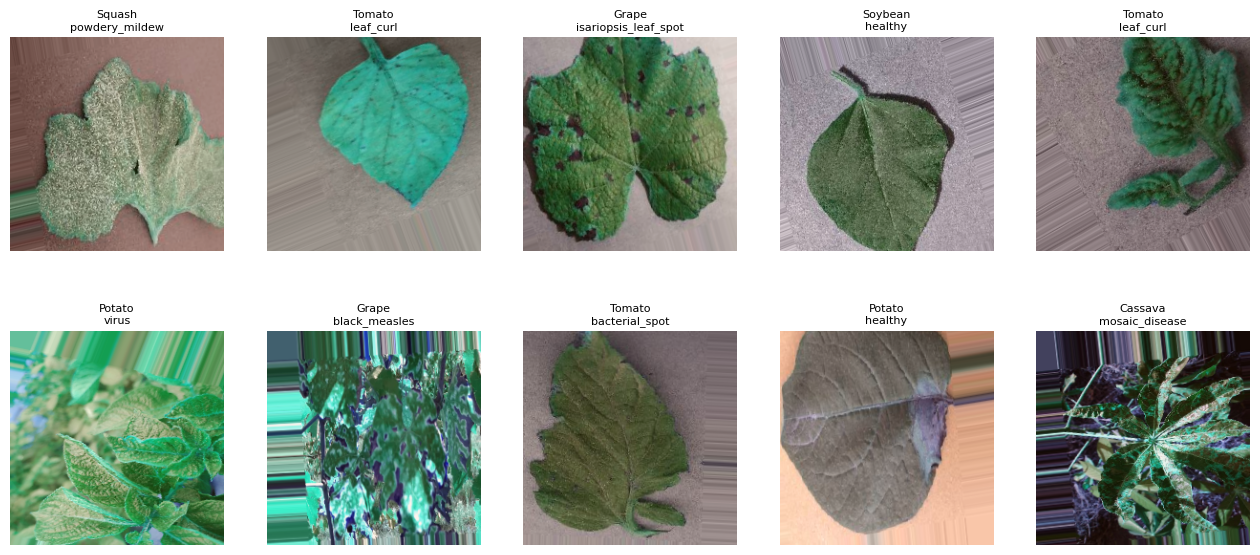

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# imgs, labels = next(train_gen)

# fig, axes = plt.subplots(2, 5, figsize=(16, 7))
# for i, ax in enumerate(axes.flat):
#     ax.imshow(imgs[i])
#     class_idx = np.argmax(labels[i])
#     ax.set_title(CLASS_NAMES[class_idx].replace("___", "\n"), fontsize=8)
#     ax.axis("off")
# plt.suptitle("Sample Augmented Training Images", fontsize=13, fontweight="bold")
# plt.tight_layout()
# plt.show()
imgs, labels = next(train_gen)

# Convert to displayable format
imgs = imgs.copy()
imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx].replace("___", "\n"), fontsize=8)
    ax.axis("off")

plt.show()

## 3 · Build & inspect ResNet50

In [6]:
from src.resnet_model import build_resnet50

# Build with base frozen (Phase 1 configuration)
model = build_resnet50(
    num_classes = train_gen.num_classes,
    input_shape = IMAGE_SIZE + (3,),
    freeze_base = True,
)

# Quick sanity: forward pass on one batch
test_batch  = imgs[:2]                       # 2 images from the sample above
test_output = model.predict(test_batch, verbose=0)
print("Output shape :", test_output.shape)   # should be (2, 53)
print("Probabilities sum to 1:", np.allclose(test_output.sum(axis=1), 1.0))

[resnet_model] Built ResNet50 | classes=58 | base_frozen=True


Model: "ResNet50_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50 (Functional)             │ (None, 7, 7, 2048)       │    23,587,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       524,544 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 58)               │        14,906 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 24,127,162 (92.04 MB)

 Trainable params: 539,450 (2.06 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Output shape : (2, 58)
Probabilities sum to 1: False


In [7]:
print("Class mode:", train_gen.class_mode)

images, labels = next(train_gen)
print("Labels shape:", labels.shape)

Class mode: categorical
Labels shape: (16, 58)


In [8]:
print("NUM_CLASSES (generator):", train_gen.num_classes)
print("Model output:", model.output_shape)

NUM_CLASSES (generator): 58
Model output: (None, 58)


In [9]:
print("Model output shape:", model.output_shape)

Model output shape: (None, 58)


In [10]:
print("Classes:", train_gen.num_classes)
print("Model output:", model.output_shape)

images, labels = next(train_gen)
print("Labels shape:", labels.shape)

Classes: 58
Model output: (None, 58)
Labels shape: (16, 58)


## 4 · Train (Phase 1 – head only)

In [11]:
from src.resnet_model import get_callbacks

callbacks = get_callbacks(MODEL_SAVE, patience=7)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_PHASE1,
    callbacks       = callbacks,
    verbose         = 1,    
    steps_per_epoch  = train_gen.samples // train_gen.batch_size,
    validation_steps = val_gen.samples // val_gen.batch_size
)

print("\nPhase 1 best val_accuracy:",
      max(history1.history["val_accuracy"]))

Epoch 1/5
4712/4712 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6903 - loss: 1.0833
Epoch 1: val_accuracy improved from None to 0.83147, saving model to ../models/resnet_model.h5


4712/4712 ━━━━━━━━━━━━━━━━━━━━ 12150s 3s/step - accuracy: 0.7688 - loss: 0.7284 - val_accuracy: 0.8315 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 2/5
   1/4712 ━━━━━━━━━━━━━━━━━━━━ 1:31:37 1s/step - accuracy: 0.8125 - loss: 1.0464

c:\Users\Prakash Choudhary\Desktop\Work\Freelancing\Plants Disease detection\Addy\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.83147 to 0.83179, saving model to ../models/resnet_model.h5


4712/4712 ━━━━━━━━━━━━━━━━━━━━ 1213s 257ms/step - accuracy: 0.8125 - loss: 1.0464 - val_accuracy: 0.8318 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 3/5
2691/4712 ━━━━━━━━━━━━━━━━━━━━ 1:07:12 2s/step - accuracy: 0.8211 - loss: 0.5227

KeyboardInterrupt: 

## 5 · Fine-tune (Phase 2 – last 20 base layers)

In [ ]:
from src.resnet_model import unfreeze_last_n_layers

# Unfreeze last 20 layers of ResNet50 base, lower LR
model = unfreeze_last_n_layers(model, n_layers=10, new_lr=1e-5)

callbacks2 = get_callbacks(MODEL_SAVE, patience=5)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_PHASE2,
    callbacks       = callbacks2,
    verbose         = 1,
)

print("\nPhase 2 best val_accuracy:",
      max(history2.history["val_accuracy"]))

[resnet_model] Fine-tuning: 20 / 175 base layers trainable | lr=1e-05
Epoch 1/10
  2/500 ━━━━━━━━━━━━━━━━━━━━ 5:23:36 39s/step - accuracy: 0.6719 - loss: 0.9892

KeyboardInterrupt: 

## 6 · Training curves

In [ ]:
from src.utils import plot_training_history

plot_training_history(
    history1,
    history2,
    model_name = "ResNet50",
    save_path  = "../models/resnet_history.png",
)

NameError: name 'history1' is not defined

## 7 · Evaluate on validation set

In [ ]:
# Load the best saved weights
from tensorflow.keras.models import load_model

best_model = load_model(MODEL_SAVE)

val_loss, val_acc = best_model.evaluate(val_gen, verbose=1)
print(f"\n✅  Val Loss     : {val_loss:.4f}")
print(f"✅  Val Accuracy : {val_acc:.4f}")

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2791s 2s/step - accuracy: 0.8289 - loss: 0.6251

✅  Val Loss     : 0.6251
✅  Val Accuracy : 0.8289


## 8 · Confusion matrix

[utils] Running predictions for confusion matrix …
[utils] Confusion matrix saved → ../models/resnet_confusion_matrix.png


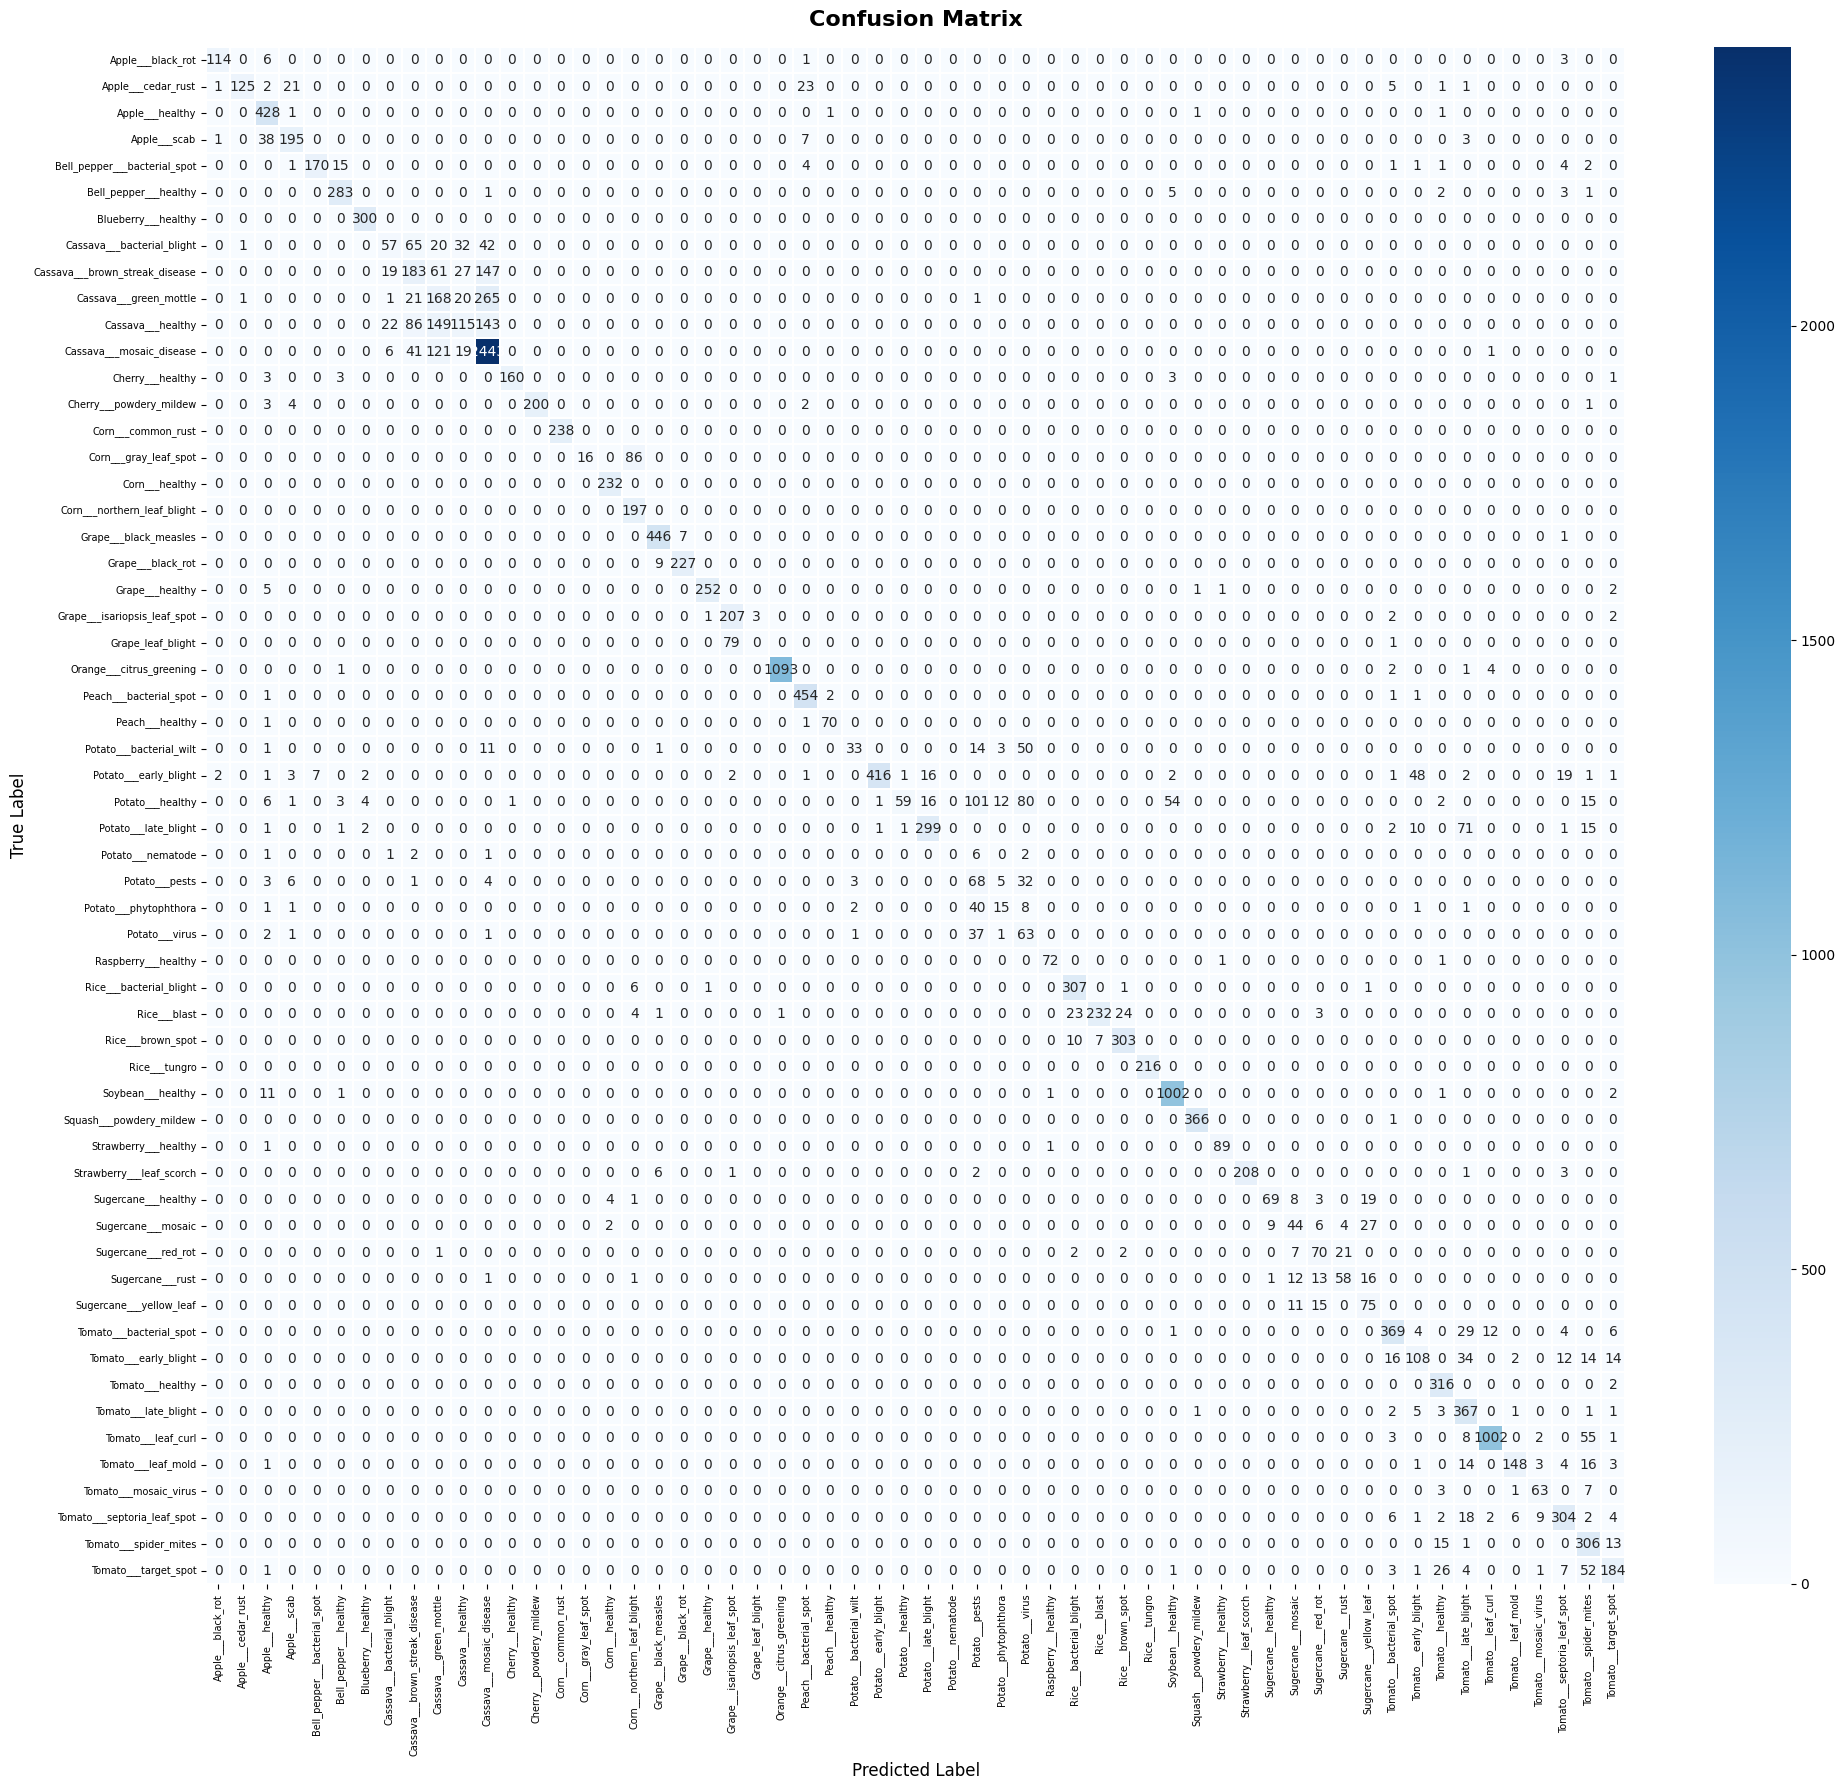


                                precision    recall  f1-score   support

             Apple___black_rot      0.966     0.919     0.942       124
            Apple___cedar_rust      0.984     0.698     0.817       179
               Apple___healthy      0.828     0.991     0.902       432
                  Apple___scab      0.833     0.799     0.816       244
  Bell_pepper___bacterial_spot      0.960     0.854     0.904       199
         Bell_pepper___healthy      0.922     0.959     0.940       295
           Blueberry___healthy      0.974     1.000     0.987       300
    Cassava___bacterial_blight      0.538     0.263     0.353       217
Cassava___brown_streak_disease      0.459     0.419     0.438       437
        Cassava___green_mottle      0.323     0.352     0.337       477
             Cassava___healthy      0.540     0.223     0.316       515
      Cassava___mosaic_disease      0.799     0.929     0.859      2631
              Cherry___healthy      0.994     0.941     0.967 

c:\Users\Prakash Choudhary\Desktop\Work\Freelancing\Plants Disease detection\Addy\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prakash Choudhary\Desktop\Work\Freelancing\Plants Disease detection\Addy\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Prakash Choudhary\Desktop\Work\Freelancing\Plants Disease detection\Addy\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

In [ ]:
from src.utils import plot_confusion_matrix

# Reset generator before iterating
val_gen.reset()

plot_confusion_matrix(
    best_model,
    val_gen,
    CLASS_NAMES,
    save_path = "../models/resnet_confusion_matrix.png",
)